# 02 Exploratory Data Analysis - Price Trends
Analyzes price trajectories, stock availability, retailer markup over MSRP, and offline vendor quote comparisons.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

workspace_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

from src.io_utils import load_sample_dataset
from src.clean_prices import clean_price_observations
from src.normalize_prices import normalize_price_series

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Data & Compute Normalized Prices

In [2]:
products_df = load_sample_dataset("products.csv")
listings_df = load_sample_dataset("product_listings.csv")
obs_df = load_sample_dataset("daily_price_observations.csv")

cleaned_obs = clean_price_observations(obs_df)
norm_df = normalize_price_series(cleaned_obs, listings_df, products_df)
display(norm_df.head())

,observation_id,listing_id,date,price_inr,in_stock,shipping_cost_inr,is_local_quote,sku_id,retailer_id,chipset,brand,model_name,vram_gb,msrp_inr,is_reference_spec,total_effective_price_inr,msrp_premium_ratio,ref_sku_daily_price_inr,premium_over_reference
0,OBS-1008,LST-5060TI-16G-ASUS-MD,2026-06-01,64200,True,0,False,RTX5060TI-16G-ASUS-DUAL,MDCOMPUTERS,RTX 5060 Ti,ASUS,ASUS Dual GeForce RTX 5060 Ti 16GB GDDR7 OC Ed...,16,49999,False,64200,1.284,81500.0,0.7877
1,OBS-1021,LST-5060TI-16G-ASUS-MD,2026-06-05,66200,True,0,False,RTX5060TI-16G-ASUS-DUAL,MDCOMPUTERS,RTX 5060 Ti,ASUS,ASUS Dual GeForce RTX 5060 Ti 16GB GDDR7 OC Ed...,16,49999,False,66200,1.324,84000.0,0.7881
2,OBS-1034,LST-5060TI-16G-ASUS-MD,2026-06-10,68800,True,0,False,RTX5060TI-16G-ASUS-DUAL,MDCOMPUTERS,RTX 5060 Ti,ASUS,ASUS Dual GeForce RTX 5060 Ti 16GB GDDR7 OC Ed...,16,49999,False,68800,1.376,87500.0,0.7863
3,OBS-1047,LST-5060TI-16G-ASUS-MD,2026-06-15,71800,True,0,False,RTX5060TI-16G-ASUS-DUAL,MDCOMPUTERS,RTX 5060 Ti,ASUS,ASUS Dual GeForce RTX 5060 Ti 16GB GDDR7 OC Ed...,16,49999,False,71800,1.436,91200.0,0.7873
4,OBS-1060,LST-5060TI-16G-ASUS-MD,2026-06-20,74900,True,0,False,RTX5060TI-16G-ASUS-DUAL,MDCOMPUTERS,RTX 5060 Ti,ASUS,ASUS Dual GeForce RTX 5060 Ti 16GB GDDR7 OC Ed...,16,49999,False,74900,1.498,95000.0,0.7884


## 2. Visualize Price Trends Across SKUs

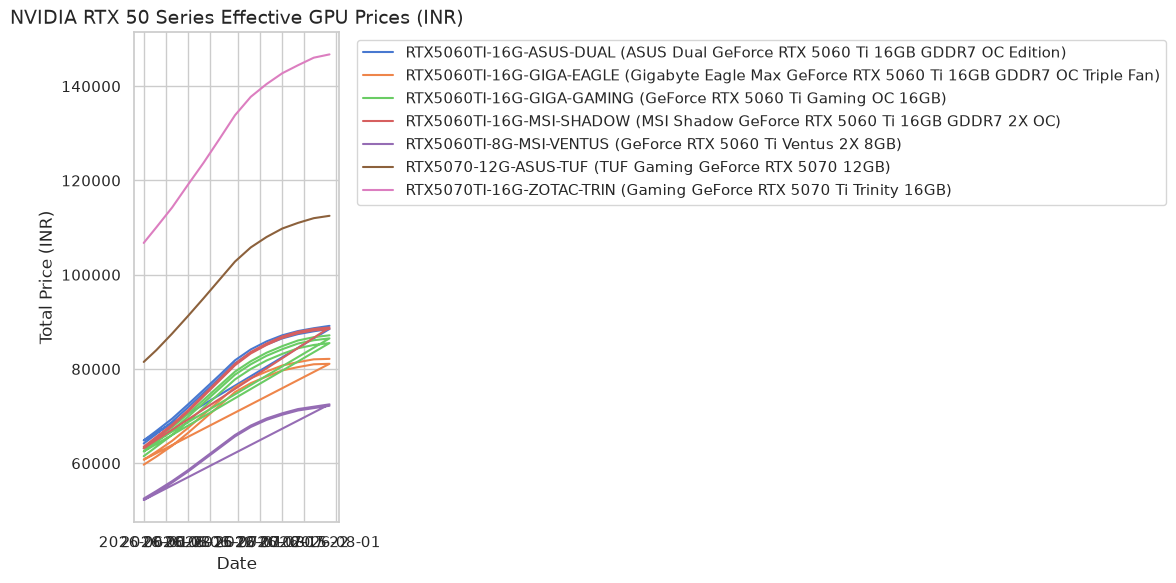

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for sku_id, group in norm_df.groupby("sku_id"):
    model_name = group["model_name"].iloc[0]
    ax.plot(group["date"], group["total_effective_price_inr"], label=f"{sku_id} ({model_name})")

ax.set_title("NVIDIA RTX 50 Series Effective GPU Prices (INR)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Price (INR)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Retailer Spread & Local Vendor Quote Comparison

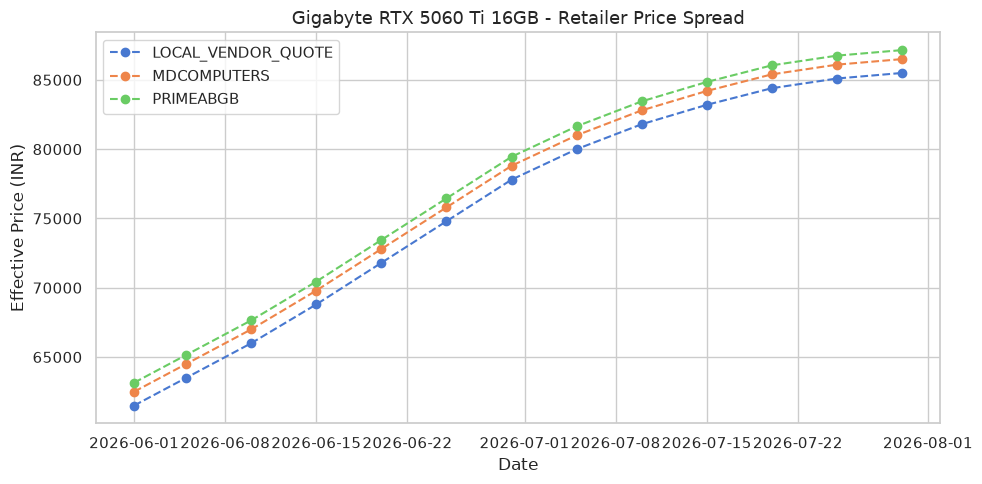

In [4]:
r5060ti_16g = norm_df[norm_df["sku_id"] == "RTX5060TI-16G-GIGA-GAMING"]
fig, ax = plt.subplots(figsize=(10, 5))
for retailer, group in r5060ti_16g.groupby("retailer_id"):
    ax.plot(group["date"], group["total_effective_price_inr"], marker='o', linestyle='--', label=retailer)

ax.set_title("Gigabyte RTX 5060 Ti 16GB - Retailer Price Spread", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Effective Price (INR)")
ax.legend()
plt.tight_layout()
plt.show()